# Air Brakes

Air brakes are commonly used in rocketry to slow down a rocket's ascent. They are usually deployed to make sure that the rocket reaches a certain altitude.

Lets make a simple air brakes example. We will use the same model as in the [First Simulation](first_simulation.ipynb) example, but we will add a simple air brakes model.

In [1]:
!python -m pip install -e ../../.

Obtaining file:///home/mohammed/Continuous-Discrete-Control
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for rocketpy (pyproject.toml) ... done
  Created wheel for rocketpy: filename=rocketpy-1.12.0-0.editable-py3-none-any.whl size=10236 sha256=5c6f90a6180c47528f749068d015e0d767f1ee943ebf2026e17835a71add8de7
  Stored in directory: /tmp/pip-ephem-wheel-cache-q9f9iehc/wheels/b1/53/d7/7bd4a1ccdf1c1e41867247b9bb47faafbcb1d77b4d69105f1c
Successfully built rocketpy
  Attempting uninstall: rocketpy
    Found existing installation: rocketpy 1.12.0
    Uninstalling rocketpy-1.12.0:
      Successfully uninstalled rocketpy-1.12.0


## Setting Up The Simulation

First, lets define everything we need for the simulation up to the rocket:

In [2]:
from rocketpy import Environment, SolidMotor, Rocket, Flight

env = Environment(latitude=32.990254, longitude=-106.974998, elevation=1400)

Pro75M1670 = SolidMotor(
    thrust_source="../../data/motors/cesaroni/Cesaroni_M1670.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

calisto = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="../../data/rockets/calisto/powerOffDragCurve.csv",
    power_on_drag="../../data/rockets/calisto/powerOnDragCurve.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)

rail_buttons = calisto.set_rail_buttons(
    upper_button_position=0.0818,
    lower_button_position=-0.618,
    angular_position=45,
)

calisto.add_motor(Pro75M1670, position=-1.255)

nose_cone = calisto.add_nose(
    length=0.55829, kind="vonKarman", position=1.278
)

fin_set = calisto.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.060,
    span=0.110,
    position=-1.04956,
    cant_angle=0.5,
    airfoil=("../../data/airfoils/NACA0012-radians.txt","radians"),
)

tail = calisto.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)

## Setting Up the Air Brakes

Now we can get started!

To create an air brakes model, we essentially need to define the following:

- The air brakes' **drag coefficient** as a function of the air brakes' **deployment level** and of the **Mach number**. This can be done through a `CSV` file which must have three columns: the first column is the air brakes' **deployment level**, the second column is the **Mach number**, and the third column is the **drag coefficient** added to rocket due to the air brakes at that specific deployment level and Mach number.

- The **controller function**, which takes in as argument information about the simulation up to the current time step, and the `AirBrakes` instance being defined, and sets the desired air brakes' deployment level. The air brakes' deployment level must be between 0 and 1, and is set using the `deployment_level` attribute. Inside this function, any controller logic, filters, and apogee prediction can be implemented.

- The **sampling rate** of the controller function, in seconds. This is the time between each call of the controller function, in simulation time. Must be given in Hertz.

### Defining the Controller Function

Lets start by defining a very simple controller function.

The `controller_function` must take in the following arguments, in this order:

1. `time` (float): The current simulation time in seconds.
2. `sampling_rate` (float): The rate at which the controller function is called, measured in Hertz (Hz).
3. `state` (list): The state vector of the simulation. The state is a list containing the following values, in this order:
   - `x`: The x position of the rocket, in meters.
   - `y`: The y position of the rocket, in meters.
   - `z`: The z position of the rocket, in meters.
   - `v_x`: The x component of the velocity of the rocket, in meters per second.
   - `v_y`: The y component of the velocity of the rocket, in meters per second.
   - `v_z`: The z component of the velocity of the rocket, in meters per second.
   - `e0`: The first component of the quaternion representing the rotation of the rocket.
   - `e1`: The second component of the quaternion representing the rotation of the rocket.
   - `e2`: The third component of the quaternion representing the rotation of the rocket.
   - `e3`: The fourth component of the quaternion representing the rotation of the rocket.
   - `w_x`: The x component of the angular velocity of the rocket, in radians per second.
   - `w_y`: The y component of the angular velocity of the rocket, in radians per second.
   - `w_z`: The z component of the angular velocity of the rocket, in radians per second.

4. `state_history` (list): A record of the rocket's state at each step throughout the simulation. The state_history is organized as a list of lists, with each sublist containing a state vector. The last item in the list always corresponds to the previous state vector.

5. `observed_variables` (list): A list containing the variables that the controller function returns. The return of each controller function call is appended to the observed_variables list. The initial value is provided by the `initial_observed_variables` argument.

6. `air_brakes` (AirBrakes): The `AirBrakes` instance being controlled.

Our example `controller_function` will deploy the air brakes when the rocket reaches 1500 meters above the ground. The deployment level will be a function of the vertical velocity at the current time step and the vertical velocity at the previous time step.

Also, the controller function will check for burnout of the rocket's motor and only deploy the air brakes if burnout has been reached.

A limitation for the opening/closing speed of the air brakes will be set. The air brakes deployment level will not be able to change faster than 20% per second.

In [4]:
def controller_function(
    time, sampling_rate, state, state_history, observed_variables, air_brakes
):
    # state = [x, y, z, vx, vy, vz, e0, e1, e2, e3, wx, wy, wz]
    altitude_ASL = state[2]
    altitude_AGL = altitude_ASL - env.elevation
    vx, vy, vz = state[3], state[4], state[5]

    # Get winds in x and y directions
    wind_x = env.wind_velocity_x(altitude_ASL)
    wind_y = env.wind_velocity_y(altitude_ASL)

    # Calculate Mach number
    free_stream_speed = (
        (wind_x - vx) ** 2 + (wind_y - vy) ** 2 + (vz) ** 2
    ) ** 0.5
    mach_number = free_stream_speed / env.speed_of_sound(altitude_ASL)

    # Get previous state from state_history
    previous_state = state_history[-1]
    previous_vz = previous_state[5]

    # If we wanted to we could get the returned values from observed_variables:
    # returned_time, deployment_level, drag_coefficient = observed_variables[-1]

    # Check if the rocket has reached burnout
    if time < Pro75M1670.burn_out_time:
        return None

    # If below 1500 meters above ground level, air_brakes are not deployed
    if altitude_AGL < 1500:
        air_brakes.deployment_level = 0

    # Else calculate the deployment level
    else:
        # Controller logic
        new_deployment_level = (
            air_brakes.deployment_level + 0.1 * vz + 0.01 * previous_vz**2
        )

        # Limiting the speed of the air_brakes to 0.2 per second
        # Since this function is called every 1/sampling_rate seconds
        # the max change in deployment level per call is 0.2/sampling_rate
        max_change = 0.2 / sampling_rate
        lower_bound = air_brakes.deployment_level - max_change
        upper_bound = air_brakes.deployment_level + max_change
        new_deployment_level = min(
            max(new_deployment_level, lower_bound), upper_bound
        )

        air_brakes.deployment_level = new_deployment_level

    # Return variables of interest to be saved in the observed_variables list
    return (
        time,
        air_brakes.deployment_level,
        air_brakes.drag_coefficient(air_brakes.deployment_level, mach_number),
    )

**Note:**
- The code inside the `controller_function` can be as complex as needed. Anything can be implemented, including filters and apogee prediction.
- The `air_brakes` instance `deployment_level` is clamped between 0 and 1.
- Anything can be returned by the `controller_function`. The returned values will be saved in the `observed_variables` list.
- The `controller_function` can be defined in a separate file and imported.

### Defining the Drag Coefficient

Now lets define the drag coefficient as a function of the air brakes' deployment level and Mach number. We will import the data from a CSV file.

The CSV file must have three columns: deployment level, Mach number, and drag coefficient.

Alternatively, the drag coefficient can be defined as a function that takes deployment level and Mach number as arguments.

**Note:** At deployment level 0, the drag coefficient is always set to 0, regardless of the input curve.

Part of the data from the CSV:

```
deployment_level, mach, cd
0.0, 0.0, 0.0
0.1, 0.0, 0.0
0.1, 0.2, 0.0
0.1, 0.3, 0.01
0.1, 0.4, 0.005
0.1, 0.5, 0.006
0.1, 0.6, 0.018
0.1, 0.7, 0.012
0.1, 0.8, 0.014
0.5, 0.1, 0.051
0.5, 0.2, 0.051
0.5, 0.3, 0.065
0.5, 0.4, 0.061
0.5, 0.5, 0.067
0.5, 0.6, 0.083
0.5, 0.7, 0.08
0.5, 0.8, 0.085
1.0, 0.1, 0.32
1.0, 0.2, 0.225
1.0, 0.3, 0.225
1.0, 0.4, 0.21
1.0, 0.5, 0.19
1.0, 0.6, 0.22
1.0, 0.7, 0.21
1.0, 0.8, 0.218
```

**Note:** The air brakes' drag coefficient curve can represent either:
- The air brakes alone (added to the rocket's drag), or
- Both the air brakes and the rocket together (overrides the rocket's drag)

This is determined by the `override_rocket_drag` argument.

### Adding the Air Brakes to the Rocket

Now we can add the air brakes to the rocket. We will set the `reference_area` to `None` (uses rocket's reference area) and `clamp` to `True` (clamps deployment level between 0 and 1).

In [ ]:
air_brakes = calisto.add_air_brakes(
    drag_coefficient_curve="../../data/rockets/calisto/air_brakes_cd.csv",
    controller_function=controller_function,
    sampling_rate=10,
    reference_area=None,
    clamp=True,
    initial_observed_variables=[0, 0, 0],
    override_rocket_drag=False,
    name="Air Brakes",
)

air_brakes.all_info()

**Note:** The `initial_observed_variables` argument is optional and provides the initial value for the `observed_variables` list passed to the controller function at the first time step.

### Alternative: Using `add_discrete_controller()`

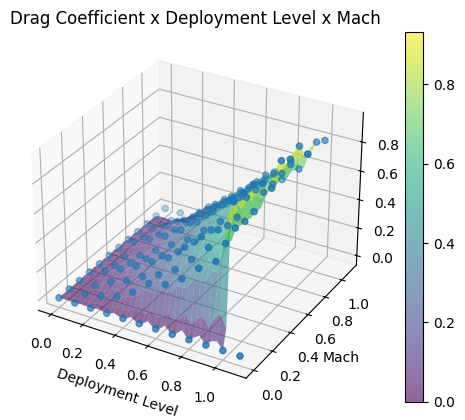

In [5]:
from rocketpy.rocket.aero_surface import AirBrakes

air_brakes_dis = AirBrakes(
    drag_coefficient_curve="../../data/rockets/calisto/air_brakes_cd.csv",
    reference_area=calisto.area,
    clamp=True,
    override_rocket_drag=False,
    deployment_level=0,
    name="Air Brakes (Dis)"
)

calisto.add_discrete_controller(
    controller_function=controller_function,
    refresh_rate=10,
    interactive_objects=air_brakes_dis,
    initial_observed_variables=[0, 0, 0],
    name="Discrete Air Brakes Controller"
)

calisto.air_brakes.append(air_brakes_dis)

air_brakes_dis.all_info()

## Simulating a Flight

**Important:** To simulate the air brakes successfully, we must set `time_overshoot` to `False`. This way the simulation will run at the time step defined by our controller sampling rate. Be aware that this will make the simulation run **much** slower.

We will terminate the simulation at apogee by setting `terminate_on_apogee` to `True`.

In [6]:
test_flight = Flight(
    rocket=calisto,
    environment=env,
    rail_length=5.2,
    inclination=85,
    heading=0,
    time_overshoot=False,
    terminate_on_apogee=True,
)

## Analyzing the Results

Now we can create some plots to analyze the results. We rely on the `observed_variables` list to get the data we want to plot. We can retrieve the `observed_variables` list by calling the `get_controller_observed_variables` method of the `Flight` instance.

[[0, 0, 0], (3.9000000000000004, 0, 0.010471111441867917), (3.9000000000000004, 0, 0.010471111441867917), (4.0, 0, 0.00811753723125519), (4.0, 0, 0.00811753723125519), (4.1000000000000005, 0, 0.0053146608610413525), (4.1000000000000005, 0, 0.0053146608610413525), (4.2, 0, 0.0028806262389872977), (4.2, 0, 0.0028806262389872977), (4.3, 0, 0.00121583942789769), (4.3, 0, 0.00121583942789769), (4.4, 0, 0.00033690501069990144), (4.4, 0, 0.00033690501069990144), (4.5, 0, 3.256022294141643e-05), (4.5, 0, 3.256022294141643e-05), (4.6000000000000005, 0, 1.7969039072312563e-07), (4.6000000000000005, 0, 1.7969039072312563e-07), (4.7, 0, 7.966473349460864e-05), (4.7, 0, 7.966473349460864e-05), (4.800000000000001, 0, 0.0005121724746861188), (4.800000000000001, 0, 0.0005121724746861188), (4.9, 0, 0.0015601901979664613), (4.9, 0, 0.0015601901979664613), (5.0, 0, 0.0033736643455058273), (5.0, 0, 0.0033736643455058273), (5.1000000000000005, 0, 0.0058951800228241764), (5.1000000000000005, 0, 0.0058951800

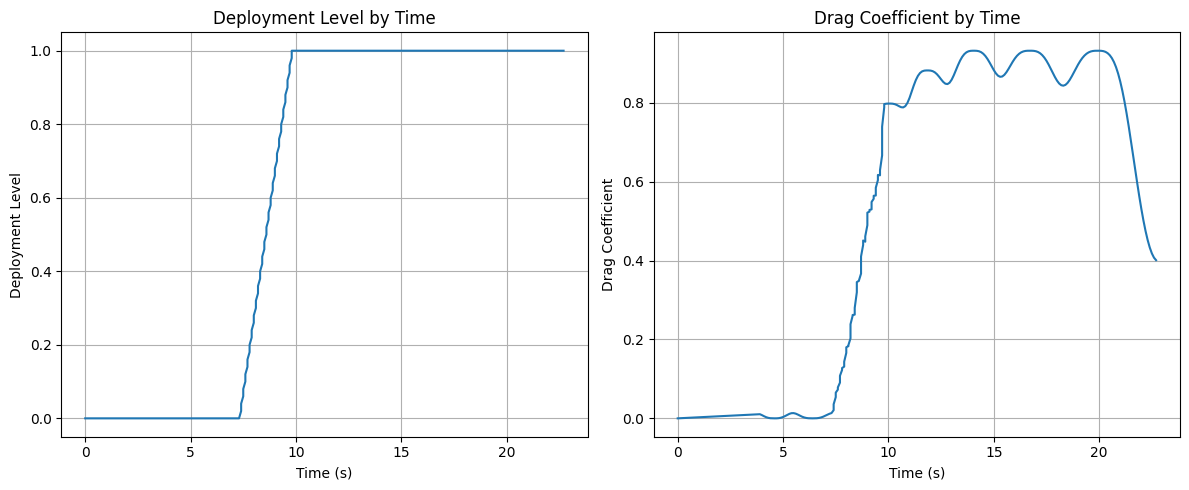

In [ ]:
import matplotlib.pyplot as plt
time_list, deployment_level_list, drag_coefficient_list = [], [], []

obs_vars = test_flight.get_controller_observed_variables()

for time, deployment_level, drag_coefficient in obs_vars:
    time_list.append(time)
    deployment_level_list.append(deployment_level)
    drag_coefficient_list.append(drag_coefficient)

# Plot deployment level by time
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_list, deployment_level_list)
plt.xlabel("Time (s)")
plt.ylabel("Deployment Level")
plt.title("Deployment Level by Time")
plt.grid()

# Plot drag coefficient by time
plt.subplot(1, 2, 2)
plt.plot(time_list, drag_coefficient_list)
plt.xlabel("Time (s)")
plt.ylabel("Drag Coefficient")
plt.title("Drag Coefficient by Time")
plt.grid()
plt.tight_layout()
plt.show()

Finally, let's check some of the simulation results:

In [8]:
test_flight.prints.burn_out_conditions()
test_flight.prints.apogee_conditions()
print(f"\nMaximum altitude: {test_flight.altitude(test_flight.apogee_time):.2f} m")
print(f"Vertical velocity at apogee: {test_flight.vz(test_flight.apogee_time):.4f} m/s")


Burn out State

Burn out time: 3.900 s
Altitude at burn out: 2057.373 m (ASL) | 657.373 m (AGL)
Rocket speed at burn out: 279.644 m/s
Freestream velocity at burn out: 279.644 m/s
Mach Number at burn out: 0.843
Kinetic energy at burn out: 6.350e+05 J

Apogee State

Apogee Time: 22.776 s
Apogee Altitude: 4302.839 m (ASL) | 2902.839 m (AGL)
Apogee Freestream Speed: 15.591 m/s
Apogee X position: -3.800 m
Apogee Y position: 465.700 m
Apogee latitude: 32.9944416°
Apogee longitude: -106.9750387°

Maximum altitude: 2902.84 m
Vertical velocity at apogee: -0.0000 m/s


In [ ]:
test_flight.prints.burn_out_conditions()
test_flight.prints.apogee_conditions()
print(f"\nMaximum altitude: {test_flight.altitude(test_flight.apogee_time):.2f} m")
print(f"Vertical velocity at apogee: {test_flight.vz(test_flight.apogee_time):.4f} m/s")


Burn out State

Burn out time: 3.900 s
Altitude at burn out: 2057.373 m (ASL) | 657.373 m (AGL)
Rocket speed at burn out: 279.644 m/s
Freestream velocity at burn out: 279.644 m/s
Mach Number at burn out: 0.843
Kinetic energy at burn out: 6.350e+05 J

Apogee State

Apogee Time: 22.776 s
Apogee Altitude: 4302.839 m (ASL) | 2902.839 m (AGL)
Apogee Freestream Speed: 15.591 m/s
Apogee X position: -3.800 m
Apogee Y position: 465.700 m
Apogee latitude: 32.9944416°
Apogee longitude: -106.9750387°

Maximum altitude: 2902.84 m
Vertical velocity at apogee: -0.0000 m/s
